# Analyze models using pcFVA
## Setup
### Import packages

In [30]:
import logging
import re
import textwrap
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import gurobipy as gp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib_venn as mpl_venn
import numpy as np
import optlang
import pandas as pd
import seaborn as sns
import sympy
from cobra import DictList, Reaction
from cobra.flux_analysis.variability import (find_blocked_reactions,
                                             flux_variability_analysis)
from cobra.util.array import create_stoichiometric_matrix, nullspace
from mpl_toolkits.axes_grid1 import make_axes_locatable
from rbc_gem_utils import (ANNOTATION_PATH, COBRA_CONFIGURATION, CURATION_PATH,
                           DATABASE_PATH, GEM_NAME, INTERIM_PATH,
                           PARAMETERIZATION_PATH, PROCESSED_PATH, ROOT_PATH,
                           build_string, check_database_version_online,
                           check_version, compare_tables, explode_column,
                           get_annotation_df, read_cobra_model, read_rbc_model,
                           show_versions, split_string, visualize_comparison,
                           write_cobra_model)
from rbc_gem_utils.analysis.overlay import *
from rbc_gem_utils.database.uniprot import (UNIPROT_DB_TAG,
                                            UNIPROT_ISOFORM_ID_RE,
                                            UNIPROT_PATH)
from rbc_gem_utils.qc import reset_reaction_bounds, reset_subsystem_groups
from rbc_gem_utils.util import (AVOGADRO_NUMBER, DEFAULT_DRY_MASS_PER_CELL,
                                convert_gDW_to_L, convert_L_to_gDW,
                                ensure_iterable, log_msg, strip_plural)
from rbc_gem_utils.visualization import cmap_map
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from sympy import parse_expr

gp.setParam("OutputFlag", 0)
gp.setParam("LogToConsole", 0)

# Show versions of notebook
show_versions()
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"


Package Information
-------------------
rbc-gem-utils 0.0.1

Dependency Information
----------------------
beautifulsoup4                       4.12.3
bio                                 missing
cobra                                0.29.1
depinfo                               2.2.0
gurobipy                             11.0.3
matplotlib                           3.10.0
matplotlib-venn                       1.1.1
memote                               0.17.0
networkx                              3.4.2
notebook                              7.3.2
openpyxl                              3.1.5
pandas                                2.2.3
pre-commit                            4.1.0
rbc-gem-utils[database,network,vis] missing
requests                             2.32.3
scipy                                1.15.1
seaborn                              0.13.2

Build Tools Information
-----------------------
pip          24.2
setuptools 75.1.0
wheel      0.44.0

Platform Information
-------------------

### Define configuration
#### COBRA Configuration

In [2]:
COBRA_CONFIGURATION.solver = "gurobi"
# Set bound defaults much larger to prevent model loading issues
COBRA_CONFIGURATION.bounds = (-1e8, 1e8)
COBRA_CONFIGURATION

Attribute,Description,Value
solver,Mathematical optimization solver,gurobi
tolerance,"General solver tolerance (feasibility, integrality, etc.)",1e-07
lower_bound,Default reaction lower bound,-100000000.0
upper_bound,Default reaction upper bound,100000000.0
processes,Number of parallel processes,127
cache_directory,Path for the model cache,C:\Users\Alicia Key\AppData\Local\opencobra\cobrapy\Cache
max_cache_size,Maximum cache size in bytes,104857600
cache_expiration,Model cache expiration time in seconds (if any),None


## Load RBC-GEM model

In [3]:
# model_id = "RBC_GEM"

# data_path = Path(f"{ROOT_PATH}/data/analysis/OVERLAY").resolve()
# results_path = Path(f"{ROOT_PATH}{PROCESSED_PATH}/{model_id}/OVERLAY")
# results_path.mkdir(exist_ok=True, parents=True)

# imagetype = "svg"
# transparent = True
# save_figures = True

# dataset_name = "RBComics"
# pcmodel_dirpath = Path(f"{data_path}/{model_id}")
# dataset_path = Path(f"{results_path}/{dataset_name}")
# dataset_models_dirpath = Path(f"{dataset_path}/pcmodels")

# sample_prefix, time_prefix = ("S", "D")
# # Integers are easier to work with for time points
# timepoints = [10, 23, 42]

# model = read_cobra_model(filename=f"{pcmodel_dirpath}/{model_id}.xml")
# pcmodel = load_overlay_model(filename=f"{pcmodel_dirpath}/{model_id}_PC.xml")

# # For this workflow, shut off complex dilution reactions at the start
# for cplx_dilution in pcmodel.reactions.query(lambda x: isinstance(x, ComplexDilution)):
#     cplx_dilution.bounds = (0, 0)

# pcmodel

model_id = "RBC3P"

data_path = Path("../../../../data/analysis/OVERLAY").resolve()
root_path = Path("../../../..").resolve()
results_path = root_path / "data" / "processed" / model_id / "OVERLAY"
results_path.mkdir(exist_ok=True, parents=True)

imagetype = "svg"
transparent = True
save_figures = True

dataset_name = "RBComics"
pcmodel_dirpath = data_path / model_id
dataset_path = results_path / dataset_name
dataset_models_dirpath = dataset_path / "pcmodels"

sample_prefix, time_prefix = ("S", "D")
# Integers are easier to work with for time points
timepoints = [10, 23, 42]

model_filename = pcmodel_dirpath / f"{model_id}.xml"
model = read_cobra_model(filename=model_filename)
pcmodel_filename = pcmodel_dirpath / f"{model_id}_PC.xml"
pcmodel = load_overlay_model(filename=pcmodel_filename)

# For this workflow, shut off complex dilution reactions at the start
for cplx_dilution in pcmodel.reactions.query(lambda x: isinstance(x, ComplexDilution)):
    cplx_dilution.bounds = (0, 0)

pcmodel

Name,RBC3P_PC
Memory address,209c1844140
Number of metabolites,489
Number of reactions,935
Number of genes,103
Number of groups,10
Objective expression,1.0*NaKt - 1.0*NaKt_reverse_db47e
Compartments,"cytosol, extracellular space, protein compartment"


### Generate list of PC-models to load and simulate

In [4]:
def get_sample_from_id(model_id, sample_prefix=""):
    sample = model_id.rsplit("_", 2)[-2]
    try:
        return int(sample.replace(sample_prefix, ""))
    except ValueError:
        return sample


def get_time_from_id(model_id, time_prefix=""):
    time = model_id.rsplit("_", 2)[-1]
    try:
        return int(time.replace(time_prefix, ""))
    except ValueError:
        return time

In [5]:
model_names = set(
    [
        fp.parts[-1].replace(fp.suffix, "")
        for fp in list(dataset_models_dirpath.iterdir())
        if fp.parts[-1].startswith(pcmodel.id)
    ]
)
sample_model_ids = sorted(
    [
        x
        for x in model_names
        if isinstance(get_sample_from_id(x, sample_prefix), (int, float))
    ],
    key=lambda x: (
        get_sample_from_id(x, sample_prefix),
        get_time_from_id(x, time_prefix),
    ),
)
operation_model_ids = sorted(
    [
        x
        for x in model_names
        if not isinstance(get_sample_from_id(x, sample_prefix), (int, float))
    ],
    key=lambda x: (
        get_sample_from_id(x, sample_prefix),
        get_time_from_id(x, time_prefix),
    ),
)
operations = set([get_sample_from_id(x, sample_prefix) for x in operation_model_ids])
model_names = operation_model_ids + sample_model_ids
list_of_pcmodels = model_names.copy()
list_of_pcmodels

['RBC3P_PC_Mean_D10',
 'RBC3P_PC_Mean_D23',
 'RBC3P_PC_Mean_D42',
 'RBC3P_PC_Median_D10',
 'RBC3P_PC_Median_D23',
 'RBC3P_PC_Median_D42',
 'RBC3P_PC_S1_D10',
 'RBC3P_PC_S1_D23',
 'RBC3P_PC_S1_D42',
 'RBC3P_PC_S2_D10',
 'RBC3P_PC_S2_D23',
 'RBC3P_PC_S2_D42',
 'RBC3P_PC_S3_D10',
 'RBC3P_PC_S3_D23',
 'RBC3P_PC_S3_D42',
 'RBC3P_PC_S4_D10',
 'RBC3P_PC_S4_D23',
 'RBC3P_PC_S4_D42',
 'RBC3P_PC_S5_D10',
 'RBC3P_PC_S5_D23',
 'RBC3P_PC_S5_D42',
 'RBC3P_PC_S6_D10',
 'RBC3P_PC_S6_D23',
 'RBC3P_PC_S6_D42',
 'RBC3P_PC_S7_D10',
 'RBC3P_PC_S7_D23',
 'RBC3P_PC_S7_D42',
 'RBC3P_PC_S8_D10',
 'RBC3P_PC_S8_D23',
 'RBC3P_PC_S8_D42',
 'RBC3P_PC_S9_D10',
 'RBC3P_PC_S9_D23',
 'RBC3P_PC_S9_D42',
 'RBC3P_PC_S10_D10',
 'RBC3P_PC_S10_D23',
 'RBC3P_PC_S10_D42',
 'RBC3P_PC_S11_D10',
 'RBC3P_PC_S11_D23',
 'RBC3P_PC_S11_D42',
 'RBC3P_PC_S12_D10',
 'RBC3P_PC_S12_D23',
 'RBC3P_PC_S12_D42',
 'RBC3P_PC_S13_D10',
 'RBC3P_PC_S13_D23',
 'RBC3P_PC_S13_D42',
 'RBC3P_PC_S14_D10',
 'RBC3P_PC_S14_D23',
 'RBC3P_PC_S14_D42',
 'RBC3P

### Generate results using pcFVA for context specific models
Note that this can take a signficiant amount of time depending on the number of models and their sizes. Best to use a targeted approach in generating results. 
Alternatively, skip result generation and load the previously generated results.

In [6]:
verbose = True
ftype = "xml"  # In our experience, SBML/XML loads faster, but will take up to 4x more space uncompressed as compared to JSON
use_only_necessary_reactions = True
# optimum_percents = [0.00, 0.50, 0.90, 0.99]
optimum_percents = [0.00, 0.9]

# pcfva_results_dirpath = Path(f"{dataset_path}/pcFVA")
# corr_results_dirpath = Path(f"{dataset_path}/correlations")

pcfva_results_dirpath = dataset_path / "pcFVA"
corr_results_dirpath = dataset_path / "correlations"

enzyme_total_suffix = DEFAULT_ENZYME_TOTAL_SUFFIX
# Reactions in addition to the minimum for flux-expression correlations
list_of_reactions = []
# # Use to get ALL reactions in the original model
# list_of_reactions += model.reactions.list_attr("id")
# # Use to get ALL reactions in the PC model
# list_of_reactions += pcmodel.reactions.list_attr("id")

#### Generate results for subset of PC model reactions
##### Reactions necessary for all flux-expression correlation computations.
To reduce computation time, a subset of reactions can be defined. 
For flux-expression correlations, the minimum reaction set are reactions associated with genes associated and the corresponding enzyme dilution reaction for total enzyme.

In [7]:
min_reaction_list = model.reactions.query(lambda x: x.gene_reaction_rule).list_attr(
    "id"
)
enzymes_list = pcmodel.reactions.query(
    lambda x: x.id.startswith(f"ENZDL_enzyme_") and f"{enzyme_total_suffix}" in x.id
).list_attr("id")
reaction_enzymes_map = {
    rid: tuple(
        pcmodel.reactions.query(
            lambda x: x.id.startswith(f"ENZDL_enzyme_{rid}_")
        ).list_attr("id")
    )
    for rid in min_reaction_list
}
enzyme_reaction_map = {
    enzyme: rid for rid, enzymes in reaction_enzymes_map.items() for enzyme in enzymes
}
if not enzymes_list:
    enzymes_list = [
        enzyme
        for enzyme, rid in enzyme_reaction_map.items()
        if rid in min_reaction_list
    ]
min_reaction_list += enzymes_list
print(
    f"Number of reactions minimize/maximize (minimum): {len(min_reaction_list)} / {len(pcmodel.reactions)}"
)

Number of reactions minimize/maximize (minimum): 116 / 935


##### Refined set of PC model reactions

In [8]:
if use_only_necessary_reactions:
    reaction_list = min_reaction_list.copy()
else:
    list_of_reactions = [getattr(rid, "_id", rid) for rid in list_of_reactions]
    # No summation variables, only enzyme pairs
    reaction_list = sorted(
        [
            x if isinstance(x, str) else x.id
            for x in set(min_reaction_list).union(list_of_reactions)
        ]
    )
print(
    f"Number of reactions minimize/maximize (chosen):: {len(reaction_list)} / {len(pcmodel.reactions)}"
)

Number of reactions minimize/maximize (chosen):: 116 / 935


## Run pcFVA

In [9]:
run_computations = True  # Keep off to use previously computed results

pcfva_solutions = {}
index_cols = ["reactions", "optimum", "model"]
pcfva_results_dirpath.mkdir(exist_ok=True, parents=True)
if run_computations:
    for idx, pcmodel_sample in enumerate(list_of_pcmodels, start=1):
        filepath = Path(f"{pcfva_results_dirpath}/{pcmodel_sample}_FVAresults.tsv")
        if filepath.exists():
            if verbose:
                print(
                    f"{idx}) Already finished {pcmodel_sample}, will load results after finishing remaining models."
                )
            continue

        print("================================================")
        print(f"Computing pcFVA results for {pcmodel_sample}")
        print("================================================")
        if isinstance(pcmodel_sample, str):
            if verbose:
                print(f"Loading {pcmodel_sample}.")
            pcmodel_sample = load_overlay_model(
                f"{dataset_models_dirpath}/{pcmodel_sample}.{ftype}"
            )
        try:
            optimum_solutions = []
            if verbose:
                print(f"Starting simulations for {pcmodel_sample}")
            for optimum_percent in optimum_percents:
                pcfva_sol = flux_variability_analysis(
                    pcmodel_sample,
                    reaction_list=reaction_list,
                    loopless=False,
                    fraction_of_optimum=optimum_percent,
                    # processes=COBRA_CONFIGURATION.processes,
                    processes=56
                )
                pcfva_sol.index = pd.MultiIndex.from_tuples(
                    [
                        (rid, optimum_percent, pcmodel_sample.id)
                        for rid in pcfva_sol.index
                    ],
                    names=index_cols,
                )
                optimum_solutions.append(pcfva_sol)
                if verbose:
                    print(f"Finished pcFVA for percent optimum: {optimum_percent}.")
            pcfva_sol = pd.concat(optimum_solutions, axis=0)
            pcfva_sol.to_csv(filepath, sep="\t", index=True)
            pcfva_solutions[str(pcmodel_sample)] = pcfva_sol
            if verbose:
                print(f"Finished all simulations for {pcmodel_sample}")
        except Exception as e:
            if verbose:
                print(f"{pcmodel_sample} failed due to an exception.")
            with open(f"{pcfva_results_dirpath}/pcFVA-errors.log", "a") as file:
                file.write(f"{pcmodel_sample} failed due to an exception. {str(e)}\n")

    # Load missing solutions if interuptions required
    for pcmodel_sample in list_of_pcmodels:
        if pcmodel_sample in pcfva_solutions:
            continue
        filepath = Path(f"{pcfva_results_dirpath}/{pcmodel_sample}_FVAresults.tsv")
        if filepath.exists():
            pcfva_solutions[str(pcmodel_sample)] = pd.read_csv(
                filepath, sep="\t", index_col=index_cols
            )
    pcfva_solutions = {
        k: pcfva_solutions[k] for k in list_of_pcmodels if k in pcfva_solutions
    }

if pcfva_solutions:
    df_pcfva_all = pd.concat(list(pcfva_solutions.values()), axis=0)
    # Regroup solutions
    df_pcfva_all = df_pcfva_all.sort_index(level=index_cols).reset_index(drop=False)
    df_pcfva_all.to_csv(
        f"{pcfva_results_dirpath}/{pcmodel.id}_FVAresults_ALL.tsv",
        sep="\t",
        index=False,
    )
else:
    df_pcfva_all = pd.DataFrame()
df_pcfva_all

Computing pcFVA results for RBC3P_PC_Mean_D10
Loading RBC3P_PC_Mean_D10.
Starting simulations for RBC3P_PC_Mean_D10
Finished pcFVA for percent optimum: 0.0.
Finished pcFVA for percent optimum: 0.9.
Finished all simulations for RBC3P_PC_Mean_D10
Computing pcFVA results for RBC3P_PC_Mean_D23
Loading RBC3P_PC_Mean_D23.
Starting simulations for RBC3P_PC_Mean_D23
Finished pcFVA for percent optimum: 0.0.
Finished pcFVA for percent optimum: 0.9.
Finished all simulations for RBC3P_PC_Mean_D23
Computing pcFVA results for RBC3P_PC_Mean_D42
Loading RBC3P_PC_Mean_D42.
Starting simulations for RBC3P_PC_Mean_D42
Finished pcFVA for percent optimum: 0.0.
Finished pcFVA for percent optimum: 0.9.
Finished all simulations for RBC3P_PC_Mean_D42
Computing pcFVA results for RBC3P_PC_Median_D10
Loading RBC3P_PC_Median_D10.
Starting simulations for RBC3P_PC_Median_D10
Finished pcFVA for percent optimum: 0.0.
Finished pcFVA for percent optimum: 0.9.
Finished all simulations for RBC3P_PC_Median_D10
Computing pc

,reactions,optimum,model,minimum,maximum
0,ADA,0.0,RBC3P_PC_Mean_D10,0.0,4.262314
1,ADA,0.0,RBC3P_PC_Mean_D23,0.0,4.264905
2,ADA,0.0,RBC3P_PC_Mean_D42,0.0,4.262908
3,ADA,0.0,RBC3P_PC_Median_D10,0.0,4.263931
4,ADA,0.0,RBC3P_PC_Median_D23,0.0,4.264808
...,...,...,...,...,...
430123,TPI,0.9,RBC3P_PC_S99_D23,0.0,0.211217
430124,TPI,0.9,RBC3P_PC_S99_D42,0.0,0.211848
430125,TPI,0.9,RBC3P_PC_S9_D10,0.0,0.210419
430126,TPI,0.9,RBC3P_PC_S9_D23,0.0,0.209489


## Load pcFVA generated results

In [10]:
# Test to see if results were recently generated in this run, otherwise load DataFrame of generated results
try:
    assert not df_pcfva_all.empty
except (NameError, AssertionError):
    df_pcfva_all = pd.read_csv(
        f"{pcfva_results_dirpath}/{pcmodel.id}_FVAresults_ALL.tsv",
        sep="\t",
        index_col=None,
    )
    # Filter out results for models not in the desired model list
    # df_pcfva_all = df_pcfva_all[df_pcfva_all["model"].isin(list_of_pcmodels)]

df_pcfva_all

,reactions,optimum,model,minimum,maximum
0,ADA,0.0,RBC3P_PC_Mean_D10,0.0,4.262314
1,ADA,0.0,RBC3P_PC_Mean_D23,0.0,4.264905
2,ADA,0.0,RBC3P_PC_Mean_D42,0.0,4.262908
3,ADA,0.0,RBC3P_PC_Median_D10,0.0,4.263931
4,ADA,0.0,RBC3P_PC_Median_D23,0.0,4.264808
...,...,...,...,...,...
430123,TPI,0.9,RBC3P_PC_S99_D23,0.0,0.211217
430124,TPI,0.9,RBC3P_PC_S99_D42,0.0,0.211848
430125,TPI,0.9,RBC3P_PC_S9_D10,0.0,0.210419
430126,TPI,0.9,RBC3P_PC_S9_D23,0.0,0.209489


### Parse main results into smaller DataFrames
#### Seperate by reaction variable types

In [11]:
# Initialize entries with prefixes used for seperating DataFrames
dict_of_dataframes_types = {
    "reactions": None,
    "proteins": "PROTDL",
    # "complexes": "CPLXFM",
    # "complex_dilutions": "CPLXDL",
    "enzymes": "ENZDL",
    # "enzyme_formation": "ENZFM",
    "budgets": "PBDL",
    "relaxation": "RELAX",
}
for key, prefix in dict_of_dataframes_types.copy().items():
    if prefix:
        df = df_pcfva_all[
            df_pcfva_all["reactions"].apply(lambda x: x.startswith(prefix))
        ]
    else:
        df = df_pcfva_all[
            df_pcfva_all["reactions"].apply(lambda x: x in model.reactions)
        ]
    dict_of_dataframes_types[key] = df.copy()

dict_of_dataframes_types;

#### Seperate by optimum value

In [12]:
# dict_of_dataframes_opt = {
#     optimum: df_pcfva_all[df_pcfva_all["optimum"] == optimum].copy()
#     for optimum in df_pcfva_all["optimum"].unique()
# }
# print(list(dict_of_dataframes_opt))

#### Seperate by model

In [13]:
# dict_of_dataframes_model = {
#     model_id: df_pcfva_all[df_pcfva_all["model"] == model_id].copy()
#     for model_id in df_pcfva_all["model"].unique()
# }
# print(list(dict_of_dataframes_model))

### Create DataFrame for correlation calculations
#### Get maximum reaction fluxes and associated expression values

In [14]:
groupby_list = ["model", "reactions"]
always_expression_independent = [
    r.id for r in model.reactions.query(lambda x: not x.boundary and not x.genes)
]
print(
    f"Number of reactions w/o genes, always expression independent: {len(always_expression_independent)}"
)
always_expression_independent;

Number of reactions w/o genes, always expression independent: 4


##### Get maximum reaction flux

In [15]:
# Get the maximum value of the reaction flux in each direction, regardless of percent optimum
df = dict_of_dataframes_types["reactions"].copy()
df = df.groupby(groupby_list)[["minimum", "maximum"]].agg(
    {
        "minimum": "min",
        "maximum": "max",
    }
)
df_max_flux_per_model = df.abs().max(axis=1)
df_max_flux_per_model.name = "Flux"
df_max_flux_per_model

model              reactions
RBC3P_PC_Mean_D10  ADA          4.262314
                   ADEt         0.440828
                   ADK1         0.440828
                   ADNK1        0.440828
                   ADNt         4.120981
                                  ...   
RBC3P_PC_S9_D42    SPODM        2.033364
                   TALA         0.703845
                   TKT1         0.703845
                   TKT2         0.703845
                   TPI          0.836251
Name: Flux, Length: 107532, dtype: float64

##### Get maximum flux range

In [16]:
# Determine flux range
df = dict_of_dataframes_types["reactions"].copy()
df["Range"] = df["maximum"] - df["minimum"]
df_flux_range_per_model = df.groupby(groupby_list)["Range"].max()
df_flux_range_per_model

model              reactions
RBC3P_PC_Mean_D10  ADA          4.262314
                   ADEt         0.440828
                   ADK1         0.440828
                   ADNK1        0.440828
                   ADNt         4.561808
                                  ...   
RBC3P_PC_S9_D42    SPODM        2.033364
                   TALA         1.391606
                   TKT1         1.391606
                   TKT2         1.391606
                   TPI          0.836251
Name: Range, Length: 107532, dtype: float64

##### Get maximum expression

In [17]:
# Determine expression association with reaction
df = dict_of_dataframes_types["enzymes"].copy()
df["reactions"] = df["reactions"].apply(lambda x: enzyme_reaction_map[x])
df_max_enzyme_per_model = df.groupby(groupby_list)["maximum"].max()
df_max_enzyme_per_model.name = "Expression"
df_max_enzyme_per_model

model              reactions
RBC3P_PC_Mean_D10  ADA           48.270489
                   ADEt          64.176258
                   ADK1         162.463643
                   ADNK1         49.096208
                   ADNt          35.143099
                                   ...    
RBC3P_PC_S9_D42    SPODM        113.864368
                   TALA          18.763571
                   TKT1           6.685875
                   TKT2           6.685875
                   TPI           42.362017
Name: Expression, Length: 107532, dtype: float64

##### Merge into one DataFrame

In [18]:
df_reaction_flux_expression = (
    pd.merge(
        df_max_flux_per_model,
        df_flux_range_per_model,
        left_index=True,
        right_index=True,
    )
    .merge(df_max_enzyme_per_model, left_index=True, right_index=True)
    .reset_index(drop=False)
)
df_reaction_flux_expression

,model,reactions,Flux,Range,Expression
0,RBC3P_PC_Mean_D10,ADA,4.262314,4.262314,48.270489
1,RBC3P_PC_Mean_D10,ADEt,0.440828,0.440828,64.176258
2,RBC3P_PC_Mean_D10,ADK1,0.440828,0.440828,162.463643
3,RBC3P_PC_Mean_D10,ADNK1,0.440828,0.440828,49.096208
4,RBC3P_PC_Mean_D10,ADNt,4.120981,4.561808,35.143099
...,...,...,...,...,...
107527,RBC3P_PC_S9_D42,SPODM,2.033364,2.033364,113.864368
107528,RBC3P_PC_S9_D42,TALA,0.703845,1.391606,18.763571
107529,RBC3P_PC_S9_D42,TKT1,0.703845,1.391606,6.685875
107530,RBC3P_PC_S9_D42,TKT2,0.703845,1.391606,6.685875


### Define helper methods

In [28]:
def prepare_correlation_df(df, pvalue_tol):
    print(f">>> prepare_correlation_df: {list(df.columns)}")
    df["pvalue"] = df["pvalue"].apply(
        lambda x: -np.log10(x if x >= pvalue_tol else pvalue_tol)
    )
    df = df.sort_values(["pvalue", "rho"], ascending=[False, False])
    return df


def plot_correlations(
    df, ax=None, histx=True, histy=True, colorbar=True, vertical_lines=None, **kwargs
):
    # Define figure if no axes provided.
    scatter_inch = kwargs.get("scatter_inch", 5.0)
    hist_inch = kwargs.get("hist_inch", 1.0)
    hist_pad = kwargs.get("hist_pad", 0.25)
    if ax is None:
        _, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(
                scatter_inch + (hist_inch + hist_pad if histy else 0),
                scatter_inch + (hist_inch + hist_pad if histx else 0),
            ),
        )
    # X-axis is rho, Y-axis is expected as -log10(pvalue) from correlation prep
    xy = {"x": "rho", "y": "pvalue"}
    limits = {
        "x": (kwargs.get("xmin", -1.0), kwargs.get("xmax", 1.0)),
        "y": (kwargs.get("ymin", 0.0), kwargs.get("ymax", df[xy["y"]].max())),
    }
    pads = {
        axis: kwargs.get(f"{axis}pad", (limits[axis][1] - limits[axis][0]) / 2 / 20)
        for axis in list(xy)
    }
    cmap = kwargs.get("cmap", "viridis")
    zorder = kwargs.get("zorder", 2)
    edgecolor = kwargs.get("edgecolor", "black")
    edgewidth = kwargs.get("edgewidth", 0.5)
    scatter = ax.scatter(
        xy["x"],
        xy["y"],
        data=df,
        c=kwargs.get("c", xy["y"]),
        s=kwargs.get("s", 40),
        zorder=zorder,
        edgecolor=edgecolor,
        linewidth=edgewidth,
        cmap=mpl.colormaps.get_cmap(cmap) if isinstance(cmap, str) else cmap,
        norm=mpl.colors.Normalize(
            vmin=limits["y"][0] - pads["y"], vmax=limits["y"][1] + pads["y"]
        ),
    )
    ax.set_xlabel(r"Spearman Correlation $(\rho)$", fontdict={"size": "xx-large"})
    ax.set_ylabel("-log$_{10}$(p-value)", fontdict={"size": "xx-large"})
    ax.set_xlim((limits["x"][0] - pads["x"], limits["x"][1] + pads["x"]))
    ax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))

    major_ticks = {axis: kwargs.get(f"{axis}tick_major") for axis in list(xy)}
    minor_ticks = {
        axis: kwargs.get(
            f"{axis}tick_minor",
            major_ticks[axis] / 2 if major_ticks[axis] is not None else None,
        )
        for axis in list(xy)
    }
    for axis in list(xy):
        if major_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_major_locator(
                mpl.ticker.MultipleLocator(major_ticks[axis])
            )
        if minor_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_minor_locator(
                mpl.ticker.MultipleLocator(minor_ticks[axis])
            )
        ax.tick_params(axis=axis, labelsize="large")

    if vertical_lines:
        for lineval, (lineprops, textprops) in vertical_lines.items():
            if lineprops:
                ax.vlines(
                    x=lineval,
                    ymin=limits["y"][0] - pads["y"],
                    ymax=limits["y"][1] + pads["y"],
                    **lineprops,
                )
            if textprops:
                ax.text(x=lineval + pads["x"] / 2, transform=ax.transData, **textprops)

    if kwargs.get("grid", False):
        ax.grid(True, **dict(which="both", alpha=0.75))

    if colorbar:
        cax = ax.inset_axes(
            [
                limits["x"][0] - pads["x"],  # lower left corner xpos
                limits["y"][0] - pads["y"],  # lower left corner ypos
                pads["x"],  # width of colorbar
                limits["y"][1]
                + pads["y"]
                + pads[
                    "y"
                ],  # height of colorbar, need extra ypad to make up for lowering ypos
            ],
            transform=ax.transData,
        )
        cbar = ax.get_figure().colorbar(scatter, cax=cax)
        cax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))
        cax.set_xticks([])
        cax.set_yticks([])

    ax_histx = None
    ax_histy = None
    if histx or histy:
        divider = make_axes_locatable(ax)
        # Histogram axes
        ax_histx = (
            divider.append_axes("top", hist_inch, pad=hist_pad, sharex=ax)
            if histx
            else None
        )
        ax_histy = (
            divider.append_axes("right", hist_inch, pad=hist_pad, sharey=ax)
            if histy
            else None
        )

        for axis, ax_hist in zip(list(xy), [ax_histx, ax_histy]):
            if ax_hist is None:
                continue
            binwidth = kwargs.get(
                f"{axis}binwidth",
                (
                    minor_ticks[axis]
                    if minor_ticks[axis] is not None
                    else major_ticks[axis]
                ),
            )
            counts, bins, patches = ax_hist.hist(
                df[xy[axis]],
                bins=np.arange(limits[axis][0], limits[axis][1] + binwidth, binwidth),
                orientation="vertical" if axis == "x" else "horizontal",
                zorder=zorder,
                edgecolor=edgecolor,
                linewidth=edgewidth,
            )
            other = "y" if axis == "x" else "x"
            ax_hist.tick_params(
                axis=axis, **{f"label{'bottom' if axis == 'x' else 'left'}": False}
            )
            ax_hist.tick_params(axis=other, labelsize="large")
            getattr(ax_hist, f"set_{other}label")("Frequency", fontsize="large")

            tick_major_int = kwargs.get(f"hist{axis}_{other}tick_major")
            if tick_major_int is not None:
                getattr(ax_hist, f"{other}axis").set_major_locator(
                    mpl.ticker.MultipleLocator(tick_major_int)
                )
                getattr(ax_hist, f"{other}axis").set_minor_locator(
                    mpl.ticker.MultipleLocator(tick_major_int / 2)
                )
            getattr(ax_hist, f"set_{other}lim")((0, max(counts) * 1.1))
            if kwargs.get("grid", False):
                ax_hist.grid(True, **dict(which="both", alpha=0.75))

            if vertical_lines and (axis == "x" and ax_hist is not None):
                for lineval, (lineprops, _) in vertical_lines.items():
                    if lineprops:
                        ax_hist.vlines(
                            x=lineval, ymin=0.0, ymax=max(counts) * 1.1, **lineprops
                        )

    return ax, ax_histx, ax_histy

### Create subgroups of models 

In [20]:
# Don't include mean/median in correlation calculations
model_groups = {
    "ALL": [
        x
        for x in list_of_pcmodels
        if not any([op.capitalize() in x for op in operations])
    ],
    "OPERATIONS": operation_model_ids,
}
# model_groups.update({
#     f"{time_prefix}{time}": [x for x in model_groups["ALL"] if x.endswith(f"{time_prefix}{time}")]
#     for time in timepoints
# })
list(model_groups)

['ALL', 'OPERATIONS']

### Compute correlations between maximum flux and expression

In [21]:
spearman_rankings_group_dict = defaultdict(dict)
verbose = False
reaction_list = list(df_reaction_flux_expression["reactions"].unique())
corr_results_dirpath.mkdir(exist_ok=True, parents=True)

In [31]:
run_computations = True  # Will overwrite previous results
group_name = "ALL"
column_pair = ("Flux", "Expression")

if group_name in operations or group_name == "OPERATIONS":
    raise Exception("Cannot use models created using data from statistical operations.")

group_model_list = model_groups[group_name]
group_results_dir = Path(f"{corr_results_dirpath}/{group_name}")
group_results_dir.mkdir(exist_ok=True, parents=True)


filepath = Path(f"{group_results_dir}/{column_pair[0]}_{column_pair[1]}.tsv")
if filepath.exists() and not run_computations:
    print(
        "Already computed correlations between '{}' and '{}' for '{}' models".format(
            *column_pair, group_name
        )
    )
    df_correlations = pd.read_csv(f"{filepath}", sep="\t", index_col=0)
    df_correlations = df_correlations.loc[reaction_list]
elif run_computations:
    print("=========================================================================")
    print(
        "Computing correlations between '{}' and '{}' for '{}' models".format(
            *column_pair, group_name
        )
    )
    print("=========================================================================")
    correlations_dict = defaultdict(dict)
    model_list = group_model_list.copy()
    for rid in reaction_list:
        df = df_reaction_flux_expression[
            df_reaction_flux_expression["reactions"] == rid
        ]
        df = df.drop("reactions", axis=1)
        df = df.set_index("model")
        # Expected warnings emitted are due to constant input array, in which the correlation coefficient is not defined. Corresponds to the nan values.
        with warnings.catch_warnings(action="ignore"):
            rho, pvalue = spearmanr(df.loc[model_list, list(column_pair)])
        correlations_dict[rid]["rho"] = rho
        correlations_dict[rid]["pvalue"] = pvalue
        if verbose:
            print(f"For reaction {rid}: rho={rho}, p={pvalue}")
    df_correlations = pd.DataFrame.from_dict(correlations_dict, orient="index")
    df_correlations.to_csv(f"{filepath}", sep="\t", index=True)
else:
    df_correlations = pd.DataFrame()

spearman_rankings_group_dict[group_name][column_pair] = df_correlations
spearman_rankings_group_dict[group_name][column_pair]

Computing correlations between 'Flux' and 'Expression' for 'ALL' models


,rho,pvalue
ADA,0.028382,2.226434e-01
ADEt,-0.014648,5.291585e-01
ADK1,-0.057323,1.371746e-02
ADNK1,0.314025,1.423898e-43
ADNt,0.931078,0.000000e+00
ADPT,0.020034,3.893896e-01
AMPDA,1.000000,0.000000e+00
CA2t,1.000000,0.000000e+00
CAATPS1,0.342345,5.799973e-52
CO2t,1.000000,0.000000e+00


#### Export minimum and maximum ranges for dataset specific  PC model

In [32]:
df_reaction_ranges = df_pcfva_all.groupby(["reactions"]).agg(
    {
        "minimum": "min",
        "maximum": "max",
    }
)
df_reaction_ranges.to_csv(
    f"{dataset_path}/{pcmodel.id}_{dataset_name}_reaction_bounds.tsv",
    sep="\t",
    index=True,
)
df_reaction_ranges

,minimum,maximum
reactions,,
ADA,0.000000e+00,4.436926e+00
ADEt,-4.654455e-01,1.700029e-16
ADK1,-1.110223e-16,4.654455e-01
ADNK1,0.000000e+00,4.654455e-01
ADNt,-4.266844e+00,4.654455e-01
...,...,...
SPODM,0.000000e+00,2.059212e+00
TALA,-7.301483e-01,6.959665e-01
TKT1,-7.301483e-01,6.959665e-01


#### Visualize correlation results
##### Set common visualization options

In [33]:
# Consistent plot dimensions and values
pvalue_tol = 1e-320
scatter_inch = 5  # Length x width of scatter plot
hist_inch = 1  # Length or width of histogram addition
hist_pad = 0.4  # Space between scatter and histogram
cmap = "viridis"
edgecolor = "black"
edgewidth = 0.5
grid = False
zorder = 2
histx = True
histy = True

##### Visualize

>>> prepare_correlation_df: ['rho', 'pvalue']


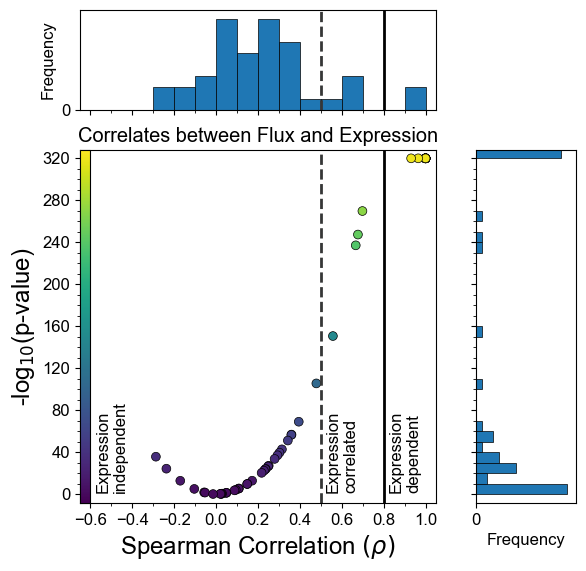

In [34]:
group_name = "ALL"  # Use models in visualizations
column_pair = ("Flux", "Expression")
xmin, xmax = (-0.60, 1.00)
xpad = 0.05

plot_kwargs = dict(
    xmin=xmin,
    xmax=xmax,
    xpad=xpad,
    edgecolor=edgecolor,
    edgewidth=edgewidth,
    cmap=cmap,
    zorder=zorder,
    scatter_inch=scatter_inch,
    hist_inch=hist_inch,
    hist_pad=hist_pad,
    grid=grid,
    xtick_major=0.2,
    xtick_minor=0.1,  # Determines minor tick and thus bin size if not otherwise set
    # xbinwidth=0.1, # Determined by minor ticks if not otherwise set
    histx_ytick_major=100,  # Major y-tick interval for histogram aligned with x-axis
    ytick_major=40,
    ytick_minor=10,  # Determines minor tick and thus bin size if not otherwise set
    # ybinwidth=10,  # Determined by minor ticks if not otherwise set
    histy_xtick_major=500,  # Major x-tick interval for histogram aligned with y-axis
)


df_corr = spearman_rankings_group_dict[group_name][column_pair].copy()
# Remove correlations that could not be calculated due to fixed/blocked flux
df_corr = df_corr[~df_corr.isna().any(axis=1)]
df_corr = prepare_correlation_df(df_corr, pvalue_tol=pvalue_tol)

# For expression lines
expression_dep_rho_lb = 0.8
expression_cor_rho_lb = 0.5
ypos = 4
ww = 11
rotation = 90
fontsize = "large"
linewidth = 2
vertical_lines = {
    expression_dep_rho_lb: (
        dict(color="black", linestyle="-", linewidth=linewidth),
        dict(
            y=ypos,
            s="\n".join(textwrap.wrap("Expression dependent", width=ww)),
            rotation=rotation,
            fontsize=fontsize,
        ),
    ),
    expression_cor_rho_lb: (
        dict(color="xkcd:dark grey", linestyle="--", linewidth=linewidth),
        dict(
            y=ypos,
            s="\n".join(textwrap.wrap("Expression correlated", width=ww)),
            rotation=rotation,
            fontsize=fontsize,
        ),
    ),
    xmin: (
        dict(),
        dict(
            y=ypos,
            s="\n".join(textwrap.wrap("Expression independent", width=ww)),
            rotation=rotation,
            fontsize=fontsize,
        ),
    ),
}


nrows, ncols = (1, 1)
fig, ax = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(
        (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
        (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
    ),
)
ax_scatter, ax_histx, ax_histy = plot_correlations(
    df_corr,
    ax=ax,
    histx=histx,
    histy=histy,
    colorbar=True,
    vertical_lines=vertical_lines,
    **plot_kwargs,
)
ax_scatter.set_title(
    f"Correlates between Flux and Expression",
    fontsize="x-large",
)
if save_figures:
    fig.savefig(
        f"{group_results_dir}/FluxExprCorrelates_{model.id}.{imagetype}",
        transparent=transparent,
        format=imagetype,
    )
fig;

### Enrich results with subsystems

In [35]:
df_pathways = pd.read_csv(
    f"{ROOT_PATH}{CURATION_PATH}/subsystems.tsv", sep="\t", index_col=0, dtype=str
)
df_pathways = df_pathways.fillna("").reset_index()
# Group "Metabolism of other amino acids" with amino acids rather than treat as "other"
df_pathways["category"] = df_pathways["category"].replace(
    "Metabolism of other amino acids", "Amino acid metabolism"
)
df_pathways = df_pathways.rename({"name": "subsystem"}, axis=1)


# Categories that should be excluded from the figure
categories_to_exclude = {"Pseudoreactions", "Model total"}
# Main categories in figure and abbreviations, all unmapped categories are mapped to "Other"
categories_to_keep = {
    "Amino acid metabolism": mpl.cm.spring,
    "Carbohydrate metabolism": mpl.cm.Greens,
    "Lipid metabolism": mpl.cm.Blues,
    "Metabolism of cofactors and vitamins": mpl.cm.summer,
    "Nucleotide metabolism": mpl.cm.winter,
    "Reactive species": mpl.cm.Reds,
    "Transport reactions": mpl.cm.Purples,
    "Other": mpl.cm.gray_r,
}
use_abbrevs = True
abbrevs = {
    "Amino acid metabolism": "A",
    "Carbohydrate metabolism": "C",
    "Lipid metabolism": "L",
    "Metabolism of cofactors and vitamins": "V",
    "Nucleotide metabolism": "N",
    "Reactive species": "R",
    "Transport reactions": "T",
    "Other": "O",
}
barsize = 0.8
cmax = 0.8
cmin = 0.15


colormaps_normal = dict(
    zip(
        categories_to_keep,
        [
            cmap_map(lambda x: x * 1, categories_to_keep[k])(cmax)
            for k in categories_to_keep
        ],
    )
)
colormaps_light = dict(
    zip(
        categories_to_keep,
        [
            cmap_map(lambda x: x / 2 + 0.5, categories_to_keep[k])(cmax)
            for k in categories_to_keep
        ],
    )
)
category_colors = {key: tuple(value(cmax)) for key, value in categories_to_keep.items()}

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Anaconda3\\envs\\RBC-GEM-akey7/data/curation/subsystems.tsv'

In [ ]:
group_name = "ALL"
column_pair = ("Flux", "Expression")
df_correlations_flux_expression = spearman_rankings_group_dict[group_name][
    column_pair
].copy()
gene_map = {
    r: build_string(sorted([g.id for g in pcmodel.reactions.get_by_id(r).genes]))
    for r in df_correlations_flux_expression.index
}
df_correlations_flux_expression.index = pd.MultiIndex.from_tuples(
    [(r, gene_map[r]) for r in df_correlations_flux_expression.index],
    names=("reaction", "genes"),
)
df_correlations_flux_expression = df_correlations_flux_expression.reset_index(
    drop=False
)
df_correlations_flux_expression = df_correlations_flux_expression.sort_values(
    ["pvalue", "rho", "genes", "reaction"], ascending=[True, False, True, True]
)
df_correlations_flux_expression = df_correlations_flux_expression.reset_index(drop=True)
df_correlations_flux_expression.to_csv(
    f"{dataset_path}/{pcmodel.id}_{dataset_name}_FLUXEXPR_CORRELATIONS.tsv",
    sep="\t",
    index=False,
)

df_correlations_flux_expression["subsystem"] = df_correlations_flux_expression[
    "reaction"
].apply(lambda x: model.reactions.get_by_id(x).subsystem)
df_correlations_flux_expression = df_correlations_flux_expression.merge(
    df_pathways[["subsystem", "category"]],
    left_on="subsystem",
    right_on="subsystem",
)
df_correlations_flux_expression["category"] = df_correlations_flux_expression[
    "category"
].apply(
    lambda x: (
        "Other" if x not in categories_to_keep and x not in categories_to_exclude else x
    )
)
df_correlations_flux_expression.to_csv(
    f"{dataset_path}/{pcmodel.id}_{dataset_name}_FLUXEXPR_CORRELATIONS.tsv",
    sep="\t",
    index=False,
)

df_blocked_w_expr = df_correlations_flux_expression[
    df_correlations_flux_expression[["rho", "pvalue"]].isna().all(axis=1)
]
df_expr_dep = df_correlations_flux_expression.loc[
    df_correlations_flux_expression[
        df_correlations_flux_expression["rho"] >= expression_dep_rho_lb
    ].index
]
df_expr_cor = df_correlations_flux_expression.loc[
    df_correlations_flux_expression[
        df_correlations_flux_expression["rho"] < expression_dep_rho_lb
    ].index
]
df_expr_cor = df_expr_cor.loc[
    df_expr_cor[df_expr_cor["rho"] >= expression_cor_rho_lb].index
]
df_expr_ind = df_correlations_flux_expression.loc[
    df_correlations_flux_expression[
        df_correlations_flux_expression["rho"] < expression_cor_rho_lb
    ].index
]


print(
    f"Number of expression dependent reactions\t({expression_dep_rho_lb} <= rho      ): {len(df_expr_dep)}"
)
print(
    f"Number of expression correlated reactions\t({expression_cor_rho_lb} <= rho < {expression_dep_rho_lb}): {len(df_expr_cor)}"
)
print(
    f"Number of expression independent reactions\t(       rho < {expression_cor_rho_lb}): {len(df_expr_ind)}"
)
print(
    f"Number of blocked reactions with associated expression:\t{len(df_blocked_w_expr)}"
)
print(
    f"Number of spontaneous reactions (no gene association):\t{len(always_expression_independent)}"
)

#### Expression dependent
##### Reactions

In [ ]:
df_counts = df_expr_dep.copy()
expr_cutoff = "$\\rho \\geq$" + f"{expression_dep_rho_lb}"

df_counts = df_counts["subsystem"].value_counts()
df_counts = (
    df_pathways[df_pathways["subsystem"] != "Pseudoreactions"][
        ["subsystem", "category"]
    ]
    .merge(
        df_counts,
        left_on="subsystem",
        right_on="subsystem",
        how="left",
    )
    .dropna()
)
df_counts["category"] = df_counts["category"].apply(
    lambda x: (
        "Other" if x not in categories_to_keep and x not in categories_to_exclude else x
    )
)
df_counts = df_counts.groupby(["category", "subsystem"])[["count"]].sum().astype(int)
df_counts = df_counts.reset_index(drop=False).sort_values(
    by=["category", "count"], ascending=[True, False]
)
df_counts_subsystem = df_counts.set_index("subsystem")
df_counts = df_counts.groupby(["category"]).agg(
    {"subsystem": lambda x: list(x), "count": "size"}
)

colors = {}
# Set colors
for category, (subsystems, size) in df_counts.iterrows():
    colors.update(
        dict(
            zip(
                subsystems,
                categories_to_keep[category](np.linspace(cmax - 0.1, cmin, size)),
            )
        )
    )

df_counts_subsystem["color"] = colors
df_counts_subsystem = df_counts_subsystem.reset_index(drop=False)
df_counts_category = df_counts_subsystem.groupby("category")[["count"]].sum()
df_counts_category["color"] = category_colors
df_counts_category["abbrev"] = {k: abbrevs[k] for k in df_counts_category.index}
df_counts_category = df_counts_category.reset_index(drop=False)


df_ring0, df_ring1 = df_counts_category, df_counts_subsystem
fig_ring, ax_ring = plt.subplots(1, 1, figsize=(3.3, 3.3))

wedgesize = 0.43
radius = 1
startangle = -30
linewidth = 0.75
edgecolor = "k"
labeldistance = 1.2

# ring_idx = 1
# labeldistance += wedgesize
# ax_ring.pie(
#     df_ring1["count"].values,
#     radius=radius + (ring_idx * wedgesize),
#     colors=df_ring1["color"].values,
#     # labels=df_ring1["name"].values,
#     wedgeprops=dict(
#         width=wedgesize, linewidth=linewidth, edgecolor=edgecolor, clip_on=False
#     ),
#     textprops={"fontsize": "large", "va": "center", "ha": "center"},
#     startangle=startangle,
# )
# Use for nice legend
labels = [
    "{}({})".format(k, v)
    for k, v in zip(
        df_ring0["abbrev"].values if use_abbrevs else df_ring0["category"].values,
        df_ring0["count"].values,
    )
]
ring_idx = 0
total = df_ring0["count"].sum()

ax_ring.pie(
    df_ring0["count"].values,
    radius=radius + (ring_idx * wedgesize),
    colors=df_ring0["color"].values,
    wedgeprops=dict(
        width=wedgesize, linewidth=linewidth, edgecolor=edgecolor, clip_on=False
    ),
    textprops={"fontsize": "x-large", "va": "center", "ha": "center"},
    startangle=startangle,
    labeldistance=labeldistance,
    labels=df_ring0["count"].values,
)
ax_ring.annotate(
    text=f"{expr_cutoff}\n{total} reactions",
    xy=(0, 0),
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize="x-large",
)
fig_ring.tight_layout()
if save_figures:
    fig_ring.savefig(
        f"{group_results_dir}/ExprDepReactions_{model_id}.{imagetype}",
        transparent=transparent,
        format=imagetype,
    )
fig_ring;

##### Genes/Proteins

In [ ]:
ticklabels_on_bars = True
hits_seperator = 50
cutoff = 10
df = df_expr_dep.copy()
df["genes"] = df["genes"].apply(split_string)
df = df.explode("genes")
list_of_genes = list(df["genes"].unique())
list_of_categories = list(df["category"].unique())

df_main = (
    pd.DataFrame.from_dict(
        {
            gene: df[df["genes"] == gene]["category"].value_counts().to_dict()
            for gene in list_of_genes
        },
        orient="index",
    )
    .fillna(0)
    .astype(int)
)
df_main.index.name = "genes"
df_main = pd.concat(
    (
        df_main,
        df.groupby("genes")["reaction"].agg(lambda x: tuple(list(x.unique()))),
    ),
    axis=1,
).reset_index(drop=False)
df_main = df_main.set_index("genes")
df_to_group = df_main[df_main.duplicated(keep=False)].reset_index(drop=False)
df_to_group = (
    df_to_group.groupby(list(df_to_group.columns[1:]))
    .agg(
        {
            "genes": lambda x: build_string(x),
        }
    )
    .reset_index(drop=False)
)
df_main = pd.concat(
    (
        df_main[~df_main.duplicated(keep=False)],
        df_to_group.set_index("genes"),
    ),
    axis=0,
)
df_main["total"] = df_main.loc[:, list_of_categories].sum(axis=1)
df_main = df_main.sort_values(by="total", ascending=False)
df_top_hits = df_main[df_main["total"] >= cutoff]
df_bot_hits = df_main[df_main["total"] < cutoff]

df_main = df_main[df_main["total"] >= cutoff]
df_upper = df_top_hits[df_top_hits["total"] > hits_seperator].sort_values(
    by="total", ascending=True
)
df_main = df_top_hits[df_top_hits["total"] <= hits_seperator]

print(df_main.shape)
df_main = df_main.sort_values(by="total", ascending=True)

if not df_upper.empty:
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(5, 10),
        height_ratios=[len(df_upper) / len(df_main), 1 - len(df_upper) / len(df_main)],
        gridspec_kw=dict(hspace=0.1),
    )
    ax_upper, ax_main = axes.flatten()
else:
    fig, ax_main = plt.subplots(nrows=1, ncols=1, figsize=(5, 10))
    ax_upper = None

df = df_main
ax = ax_main
scalar = 1
offset = np.zeros(len(df.index))
height = 0.8
for i, category in enumerate(list_of_categories):
    series = df[category]
    color = category_colors[category]
    rects = ax.barh(
        np.arange(0, len(series.index)) * 1,
        series.values,
        tick_label=series.index,
        height=height,
        left=offset,
        color=color,
        edgecolor="black",
        linewidth=0.5,
    )
    offset += series.values
    if i == len(list_of_categories) - 1 and ticklabels_on_bars:
        ax.bar_label(rects, series.index, padding=10)
        ax.set_yticklabels([])

ax.set_ymargin(0.01)
ax.set_xlim((0, scalar * 60 - 5))
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(scalar * 10))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(scalar * 10 / 2))
ax.xaxis.set_tick_params(labelsize="large")
ax.yaxis.set_tick_params(labelsize="medium")
ax.set_xlabel("Number of associated reactions", fontsize="large")

if not df_upper.empty:
    df = df_upper
    ax = ax_upper
    scalar = 5
    offset = np.zeros(len(df.index))
    for i, category in enumerate(list_of_categories):
        series = df[category]
        color = category_colors[category]
        rects = ax.barh(
            np.arange(0, len(series.index)) * 1,
            series.values,
            tick_label=series.index,
            height=height,
            left=offset,
            color=color,
            edgecolor="black",
            linewidth=0.5,
        )
        offset += series.values
        if i == len(list_of_categories) - 1 and ticklabels_on_bars:
            ax.bar_label(rects, series.index, padding=10)
            ax.set_yticklabels([])

    ax.set_ymargin(0.01)
    ax.set_xlim((0, (scalar + 1) * 50 - 25))
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(scalar * 10))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(scalar * 10 / 2))
    ax.yaxis.set_tick_params
    ax.xaxis.set_tick_params(labelsize="large")
    ax.yaxis.set_tick_params(labelsize="large")

sns.despine(fig)

if save_figures:
    fig.savefig(
        f"{group_results_dir}/ExprDepProteins_{model_id}.{imagetype}",
        transparent=transparent,
        format=imagetype,
    )
fig;

#### Expression correlated
##### Reactions

In [ ]:
df_counts = df_expr_cor.copy()
expr_cutoff = (
    f"{expression_cor_rho_lb}" + "$\\leq \\rho <$" + f"{expression_dep_rho_lb}"
)

df_counts = df_counts["subsystem"].value_counts()
df_counts = (
    df_pathways[df_pathways["subsystem"] != "Pseudoreactions"][
        ["subsystem", "category"]
    ]
    .merge(
        df_counts,
        left_on="subsystem",
        right_on="subsystem",
        how="left",
    )
    .dropna()
)
df_counts["category"] = df_counts["category"].apply(
    lambda x: (
        "Other" if x not in categories_to_keep and x not in categories_to_exclude else x
    )
)
df_counts = df_counts.groupby(["category", "subsystem"])[["count"]].sum().astype(int)
df_counts = df_counts.reset_index(drop=False).sort_values(
    by=["category", "count"], ascending=[True, False]
)
df_counts_subsystem = df_counts.set_index("subsystem")
df_counts = df_counts.groupby(["category"]).agg(
    {"subsystem": lambda x: list(x), "count": "size"}
)

colors = {}
# Set colors
for category, (subsystems, size) in df_counts.iterrows():
    colors.update(
        dict(
            zip(
                subsystems,
                categories_to_keep[category](np.linspace(cmax - 0.1, cmin, size)),
            )
        )
    )

df_counts_subsystem["color"] = colors
df_counts_subsystem = df_counts_subsystem.reset_index(drop=False)
df_counts_category = df_counts_subsystem.groupby("category")[["count"]].sum()
df_counts_category["color"] = category_colors
df_counts_category["abbrev"] = {k: abbrevs[k] for k in df_counts_category.index}
df_counts_category = df_counts_category.reset_index(drop=False)


df_ring0, df_ring1 = df_counts_category, df_counts_subsystem
fig_ring, ax_ring = plt.subplots(1, 1, figsize=(3.3, 3.3))

wedgesize = 0.43
radius = 1
startangle = -30
linewidth = 0.75
edgecolor = "k"
labeldistance = 1.2

# ring_idx = 1
# labeldistance += wedgesize
# ax_ring.pie(
#     df_ring1["count"].values,
#     radius=radius + (ring_idx * wedgesize),
#     colors=df_ring1["color"].values,
#     # labels=df_ring1["name"].values,
#     wedgeprops=dict(
#         width=wedgesize, linewidth=linewidth, edgecolor=edgecolor, clip_on=False
#     ),
#     textprops={"fontsize": "large", "va": "center", "ha": "center"},
#     startangle=startangle,
# )
# Use for nice legend
labels = [
    "{}({})".format(k, v)
    for k, v in zip(
        df_ring0["abbrev"].values if use_abbrevs else df_ring0["category"].values,
        df_ring0["count"].values,
    )
]
ring_idx = 0
total = df_ring0["count"].sum()

ax_ring.pie(
    df_ring0["count"].values,
    radius=radius + (ring_idx * wedgesize),
    colors=df_ring0["color"].values,
    wedgeprops=dict(
        width=wedgesize, linewidth=linewidth, edgecolor=edgecolor, clip_on=False
    ),
    textprops={"fontsize": "x-large", "va": "center", "ha": "center"},
    startangle=startangle,
    labeldistance=labeldistance,
    labels=df_ring0["count"].values,
)
ax_ring.annotate(
    text=f"{expr_cutoff}\n{total} reactions",
    xy=(0, 0),
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize="x-large",
)
fig_ring.tight_layout()
if save_figures:
    fig_ring.savefig(
        f"{group_results_dir}/ExprCorReactions_{model_id}.{imagetype}",
        transparent=transparent,
        format=imagetype,
    )
fig_ring;

##### Genes/Proteins

In [ ]:
ticklabels_on_bars = True
hits_seperator = 60
cutoff = 3
df = df_expr_cor.copy()
df["genes"] = df["genes"].apply(split_string)
df = df.explode("genes")
list_of_genes = list(df["genes"].unique())
list_of_categories = list(df["category"].unique())

df_main = (
    pd.DataFrame.from_dict(
        {
            gene: df[df["genes"] == gene]["category"].value_counts().to_dict()
            for gene in list_of_genes
        },
        orient="index",
    )
    .fillna(0)
    .astype(int)
)
df_main.index.name = "genes"
df_main = pd.concat(
    (
        df_main,
        df.groupby("genes")["reaction"].agg(lambda x: tuple(list(x.unique()))),
    ),
    axis=1,
).reset_index(drop=False)
df_main = df_main.set_index("genes")
df_to_group = df_main[df_main.duplicated(keep=False)].reset_index(drop=False)
df_to_group = (
    df_to_group.groupby(list(df_to_group.columns[1:]))
    .agg(
        {
            "genes": lambda x: build_string(x),
        }
    )
    .reset_index(drop=False)
)
df_main = pd.concat(
    (
        df_main[~df_main.duplicated(keep=False)],
        df_to_group.set_index("genes"),
    ),
    axis=0,
)
df_main["total"] = df_main.loc[:, list_of_categories].sum(axis=1)
df_main = df_main.sort_values(by="total", ascending=False)
df_top_hits = df_main[df_main["total"] >= cutoff]
df_bot_hits = df_main[df_main["total"] < cutoff]

df_main = df_main[df_main["total"] >= cutoff]
df_upper = df_top_hits[df_top_hits["total"] > hits_seperator].sort_values(
    by="total", ascending=True
)
df_main = df_top_hits[df_top_hits["total"] <= hits_seperator]

print(df_main.shape)
df_main = df_main.sort_values(by="total", ascending=True)

if not df_upper.empty:
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(5, 10),
        height_ratios=[len(df_upper) / len(df_main), 1 - len(df_upper) / len(df_main)],
        gridspec_kw=dict(hspace=0.1),
    )
    ax_upper, ax_main = axes.flatten()
else:
    fig, ax_main = plt.subplots(nrows=1, ncols=1, figsize=(5, 10))
    ax_upper = None

df = df_main
ax = ax_main
scalar = 1
offset = np.zeros(len(df.index))
height = 0.8
for i, category in enumerate(list_of_categories):
    series = df[category]
    color = category_colors[category]
    rects = ax.barh(
        np.arange(0, len(series.index)) * 1,
        series.values,
        tick_label=series.index,
        height=height,
        left=offset,
        color=color,
        edgecolor="black",
        linewidth=0.5,
    )
    offset += series.values
    if i == len(list_of_categories) - 1 and ticklabels_on_bars:
        ax.bar_label(rects, series.index, padding=10)
        ax.set_yticklabels([])

ax.set_ymargin(0.01)
ax.set_xlim((0, scalar * hits_seperator))
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(scalar * 10))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(scalar * 10 / 2))
ax.xaxis.set_tick_params(labelsize="large")
ax.yaxis.set_tick_params(labelsize="medium")
ax.set_xlabel("Number of associated reactions", fontsize="large")

if not df_upper.empty:
    df = df_upper
    ax = ax_upper
    scalar = 5
    offset = np.zeros(len(df.index))
    for i, category in enumerate(list_of_categories):
        series = df[category]
        color = category_colors[category]
        rects = ax.barh(
            np.arange(0, len(series.index)) * 1.0,
            series.values,
            tick_label=series.index,
            height=height,
            left=offset,
            color=color,
            edgecolor="black",
            linewidth=0.5,
        )
        offset += series.values
        if i == len(list_of_categories) - 1 and ticklabels_on_bars:
            ax.bar_label(rects, series.index, padding=10)
            ax.set_yticklabels([])
    ax.set_ymargin(0.01)
    ax.set_xlim((0, (scalar + 1) * 50 - 25))
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(scalar * 10))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(scalar * 10 / 2))
    ax.yaxis.set_tick_params
    ax.xaxis.set_tick_params(labelsize="large")
    ax.yaxis.set_tick_params(labelsize="large")

sns.despine(fig)

if save_figures:
    fig.savefig(
        f"{group_results_dir}/ExprCorProteins_{model_id}.{imagetype}",
        transparent=transparent,
        format=imagetype,
    )
fig;

#### Expression independent
##### Reactions

In [ ]:
df_counts = pd.concat((df_expr_ind, df_blocked_w_expr), axis=0)
expr_cutoff = expression_cor_rho_lb
expr_cutoff = "$\\rho <$" + f"{expression_cor_rho_lb}"

df_counts = df_counts["subsystem"].value_counts()
df_counts = (
    df_pathways[df_pathways["subsystem"] != "Pseudoreactions"][
        ["subsystem", "category"]
    ]
    .merge(
        df_counts,
        left_on="subsystem",
        right_on="subsystem",
        how="left",
    )
    .dropna()
)
df_counts["category"] = df_counts["category"].apply(
    lambda x: (
        "Other" if x not in categories_to_keep and x not in categories_to_exclude else x
    )
)
df_counts = df_counts.groupby(["category", "subsystem"])[["count"]].sum().astype(int)
df_counts = df_counts.reset_index(drop=False).sort_values(
    by=["category", "count"], ascending=[True, False]
)
df_counts_subsystem = df_counts.set_index("subsystem")
df_counts = df_counts.groupby(["category"]).agg(
    {"subsystem": lambda x: list(x), "count": "size"}
)

colors = {}
# Set colors
for category, (subsystems, size) in df_counts.iterrows():
    colors.update(
        dict(
            zip(
                subsystems,
                categories_to_keep[category](np.linspace(cmax - 0.1, cmin, size)),
            )
        )
    )

df_counts_subsystem["color"] = colors
df_counts_subsystem = df_counts_subsystem.reset_index(drop=False)
df_counts_category = df_counts_subsystem.groupby("category")[["count"]].sum()
df_counts_category["color"] = category_colors
df_counts_category["abbrev"] = {k: abbrevs[k] for k in df_counts_category.index}
df_counts_category = df_counts_category.reset_index(drop=False)


df_ring0, df_ring1 = df_counts_category, df_counts_subsystem
fig_ring, ax_ring = plt.subplots(1, 1, figsize=(3.3, 3.3))

wedgesize = 0.43
radius = 1
startangle = -30
linewidth = 0.75
edgecolor = "k"
labeldistance = 1.2

# ring_idx = 1
# labeldistance += wedgesize
# ax_ring.pie(
#     df_ring1["count"].values,
#     radius=radius + (ring_idx * wedgesize),
#     colors=df_ring1["color"].values,
#     # labels=df_ring1["name"].values,
#     wedgeprops=dict(
#         width=wedgesize, linewidth=linewidth, edgecolor=edgecolor, clip_on=False
#     ),
#     textprops={"fontsize": "large", "va": "center", "ha": "center"},
#     startangle=startangle,
# )
# Use for nice legend
labels = [
    "{}({})".format(k, v)
    for k, v in zip(
        df_ring0["abbrev"].values if use_abbrevs else df_ring0["category"].values,
        df_ring0["count"].values,
    )
]
ring_idx = 0
total = df_ring0["count"].sum()

ax_ring.pie(
    df_ring0["count"].values,
    radius=radius + (ring_idx * wedgesize),
    colors=df_ring0["color"].values,
    wedgeprops=dict(
        width=wedgesize, linewidth=linewidth, edgecolor=edgecolor, clip_on=False
    ),
    textprops={"fontsize": "x-large", "va": "center", "ha": "center"},
    startangle=startangle,
    labeldistance=labeldistance,
    labels=df_ring0["count"].values,
)
ax_ring.annotate(
    text=f"{expr_cutoff}\n{total} reactions",
    xy=(0, 0),
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize="x-large",
)
fig_ring.tight_layout()
if save_figures:
    fig_ring.savefig(
        f"{group_results_dir}/ExprIndepReactions_{model_id}.{imagetype}",
        transparent=transparent,
        format=imagetype,
    )
fig_ring;

##### Genes/Proteins

In [ ]:
ticklabels_on_bars = True
hits_seperator = 70
cutoff = 4
df = df_expr_ind.copy()
df["genes"] = df["genes"].apply(split_string)
df = df.explode("genes")
list_of_genes = list(df["genes"].unique())
list_of_categories = list(df["category"].unique())

df_main = (
    pd.DataFrame.from_dict(
        {
            gene: df[df["genes"] == gene]["category"].value_counts().to_dict()
            for gene in list_of_genes
        },
        orient="index",
    )
    .fillna(0)
    .astype(int)
)
df_main.index.name = "genes"
df_main = pd.concat(
    (
        df_main,
        df.groupby("genes")["reaction"].agg(lambda x: tuple(list(x.unique()))),
    ),
    axis=1,
).reset_index(drop=False)
df_main = df_main.set_index("genes")
df_to_group = df_main[df_main.duplicated(keep=False)].reset_index(drop=False)
df_to_group = (
    df_to_group.groupby(list(df_to_group.columns[1:]))
    .agg(
        {
            "genes": lambda x: build_string(x),
        }
    )
    .reset_index(drop=False)
)
df_main = pd.concat(
    (
        df_main[~df_main.duplicated(keep=False)],
        df_to_group.set_index("genes"),
    ),
    axis=0,
)
df_main["total"] = df_main.loc[:, list_of_categories].sum(axis=1)
df_main = df_main.sort_values(by="total", ascending=False)
df_top_hits = df_main[df_main["total"] >= cutoff]
df_bot_hits = df_main[df_main["total"] < cutoff]

df_main = df_main[df_main["total"] >= cutoff]
df_upper = df_top_hits[df_top_hits["total"] > hits_seperator].sort_values(
    by="total", ascending=True
)
df_main = df_top_hits[df_top_hits["total"] <= hits_seperator]

print(df_main.shape)
df_main = df_main.sort_values(by="total", ascending=True)

if not df_upper.empty:
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(5, 10),
        height_ratios=[len(df_upper) / len(df_main), 1 - len(df_upper) / len(df_main)],
        gridspec_kw=dict(hspace=0.1),
    )
    ax_upper, ax_main = axes.flatten()
else:
    fig, ax_main = plt.subplots(nrows=1, ncols=1, figsize=(5, 10))
    ax_upper = None

df = df_main
ax = ax_main
scalar = 1
offset = np.zeros(len(df.index))
height = 0.8
for i, category in enumerate(list_of_categories):
    series = df[category]
    color = category_colors[category]
    rects = ax.barh(
        np.arange(0, len(series.index)) * 1,
        series.values,
        tick_label=series.index,
        height=height,
        left=offset,
        color=color,
        edgecolor="black",
        linewidth=0.5,
    )
    offset += series.values
    if i == len(list_of_categories) - 1 and ticklabels_on_bars:
        ax.bar_label(rects, series.index, padding=10)
        ax.set_yticklabels([])

ax.set_ymargin(0.01)
ax.set_xlim((0, scalar * hits_seperator))
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(scalar * 10))
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(scalar * 10 / 2))
ax.xaxis.set_tick_params(labelsize="large")
ax.yaxis.set_tick_params(labelsize="medium")
ax.set_xlabel("Number of associated reactions", fontsize="large")

if not df_upper.empty:
    df = df_upper
    ax = ax_upper
    scalar = 5
    offset = np.zeros(len(df.index))
    for i, category in enumerate(list_of_categories):
        series = df[category]
        color = category_colors[category]
        rects = ax.barh(
            np.arange(0, len(series.index)) * 1.0,
            series.values,
            tick_label=series.index,
            height=height,
            left=offset,
            color=color,
            edgecolor="black",
            linewidth=0.5,
        )
        offset += series.values
        if i == len(list_of_categories) - 1 and ticklabels_on_bars:
            ax.bar_label(rects, series.index, padding=10)
            ax.set_yticklabels([])
    ax.set_ymargin(0.01)
    ax.set_xlim((0, (scalar + 1) * 50 - 25))
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(scalar * 10))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(scalar * 10 / 2))
    ax.yaxis.set_tick_params
    ax.xaxis.set_tick_params(labelsize="large")
    ax.yaxis.set_tick_params(labelsize="large")

sns.despine(fig)
if save_figures:
    fig.savefig(
        f"{group_results_dir}/ExprIndepProteins_{model_id}.{imagetype}",
        transparent=transparent,
        format=imagetype,
    )
fig;

In [ ]:
df = df_expr_dep.copy()
df["genes"] = df["genes"].apply(split_string)
df = df.explode("genes")
dep_genes = set(df["genes"].unique())
dep_genes

df = df_expr_cor.copy()
df["genes"] = df["genes"].apply(split_string)
df = df.explode("genes")
cor_genes = set(df["genes"].unique())

df = df_expr_ind.copy()
df["genes"] = df["genes"].apply(split_string)
df = df.explode("genes")
ind_genes = set(df["genes"].unique())

venn = mpl_venn.venn3(
    subsets=[dep_genes, cor_genes, ind_genes],
    set_labels=[
        "Expression\ndependent",
        "Expression\ncorrelated",
        "Expression\nindependent",
    ],
    set_colors=("xkcd:red", "xkcd:blue", "xkcd:green"),
    alpha=0.5,
    # ax=ax1,
)
circles = mpl_venn.venn3_circles(
    subsets=[dep_genes, cor_genes, ind_genes], linestyle="-", color="black", linewidth=1
)
for text in venn.set_labels:
    text.set_fontsize("x-large")
for text in venn.subset_labels:
    text.set_fontsize("x-large")

In [ ]:
asdasd

### Visualize selected flux results

In [ ]:
# DataFrame for flux values
group_name = "OPERATIONS"
sort_by = ["time", "sample"]
df_flux_all = dict_of_dataframes_types["reactions"].copy()
# df_flux_all = df_flux_all[df_flux_all["model"].isin(model_groups[group_name])]
df_flux_all["time"] = df_flux_all["model"].apply(
    lambda x: get_time_from_id(x, time_prefix=time_prefix)
)
df_flux_all["sample"] = df_flux_all["model"].apply(
    lambda x: get_sample_from_id(x, sample_prefix=sample_prefix)
)
df_flux_all = df_flux_all.sort_values(by=sort_by)

# DataFrame for expression values
df_expr_all = dict_of_dataframes_types["enzymes"].copy()
# df_expr = df_expr[df_expr["model"].isin(model_groups[group_name])]
df_expr_all["time"] = df_expr_all["model"].apply(
    lambda x: get_time_from_id(x, time_prefix=time_prefix)
)
df_expr_all["sample"] = df_expr_all["model"].apply(
    lambda x: get_sample_from_id(x, sample_prefix=sample_prefix)
)
df_expr_all = df_expr_all.sort_values(by=sort_by)

df_expr_all["reactions"] = df_expr_all["reactions"].apply(
    lambda x: enzyme_reaction_map[x]
)
df_expr_all = df_expr_all.groupby(
    ["reactions", "model", "time", "sample"], as_index=False
)["maximum"].max()
df_expr_all

In [ ]:
df_expr_all = df_expr_all.groupby(
    ["reactions", "model", "time", "sample"], as_index=False
)["maximum"].max()
df_expr_all

In [ ]:
flux_group_name = "Glycolytic"  # If using same cell for multiple different file exports, change flux_group_name to prevent file overlap


optimum_colors = {
    0.00: "xkcd:green",
    0.50: "xkcd:dark yellow",
    0.90: "xkcd:orange",
    0.99: "xkcd:red",
}
timepoint_colors = {
    "Day 10": "xkcd:white",
    "Day 23": "xkcd:light blue",
    "Day 42": "xkcd:light purple",
}

# Leave empty to remove
vline_samples = {
    # "Mean": {"color": "black", "linestyle": "--"},
    # "Median": {"color": "black", "linestyle": ":"},
}
equilibrium_line = {"color": "black", "linestyle": ":"}


legend_at_bottom = False
time_order_results = True
rank_order_results = True
sample_order_results = True  # Ignored if rank ordering
sharex, sharey = (True, True)
obj_rxn = model.reactions.query(lambda x: x.objective_coefficient)[0]

fluxes_to_plot = np.array(
    [
        ["HEX1", "PGI", "PFK", "TPI", "FBA"],  # Glycolysis
        ["GAPD", "PGK", "PGM", "ENO", "PYK"],  # Glycolysis
        ["LDH_L", "DPGM", "DPGase", "HB23DPGB", "NaKt"],  # Hemoglobin and objective
    ]
)


column_pair = ("Flux", "Expression")
df_rho = spearman_rankings_group_dict["ALL"][column_pair]["rho"]
df_fluxes_to_plot = df_flux_all[
    df_flux_all["reactions"].isin(fluxes_to_plot.flatten())
].copy()
df_expr_to_plot = df_expr_all[
    df_expr_all["reactions"].isin(fluxes_to_plot.flatten())
].copy()
df_fluxes_to_plot["span"] = df_fluxes_to_plot["maximum"] - df_fluxes_to_plot["minimum"]

# Remove mean and medians if not desired
df_fluxes_to_plot = df_fluxes_to_plot[
    ~df_fluxes_to_plot["sample"].isin(
        [
            "Mean" if "Mean" not in vline_samples else "",
            "Median" if "Median" not in vline_samples else "",
        ]
    )
]

timepoints = df_fluxes_to_plot["time"].unique()
samples = df_fluxes_to_plot["sample"].unique()
optimums = df_fluxes_to_plot["optimum"].unique()
index_points = np.arange(1, (len(samples) * len(timepoints)) + 1)

sort_by = {}
if time_order_results:
    sort_by["time"] = True
if rank_order_results:
    sort_by["span"] = True
    sort_by["maximum"] = True
    sort_by["minimum"] = True
if sample_order_results:
    sort_by["sample"] = True


nrows, ncols = fluxes_to_plot.shape
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4 * ncols, 2 * nrows),
    sharex=sharex,
    sharey=sharey,
)
axes = np.atleast_2d(axes)

mid_col_ind = int(np.ceil(axes.shape[1] / 2)) - 1
mid_row_ind = int(np.ceil(axes.shape[0] / 2)) - 1
for rid, ax in zip(fluxes_to_plot.flatten(), axes.flatten()):
    if not rid:
        fig.delaxes(ax)
        continue
    df_flux_rxn = df_fluxes_to_plot[df_fluxes_to_plot["reactions"] == rid].reset_index(
        drop=True
    )
    ymin_v, ymax_v = (
        df_fluxes_to_plot["minimum"].min() if sharey else df_flux_rxn["minimum"].min(),
        df_fluxes_to_plot["maximum"].max() if sharey else df_flux_rxn["maximum"].max(),
    )
    ypad_v = (
        df_fluxes_to_plot[["maximum", "minimum"]].abs().max(axis=1).max()
        if sharey
        else df_flux_rxn[["maximum", "minimum"]].abs().max(axis=1).max()
    ) * 0.05

    if time_order_results:
        for multiplier, (timepoint, color) in enumerate(timepoint_colors.items()):
            offset = 0
            xmin = multiplier * len(samples) - offset
            xmax = (multiplier + 1) * len(samples) - offset

            if multiplier != 0:
                ax.vlines(
                    x=xmin,
                    ymin=ymin_v - ypad_v,
                    ymax=ymax_v + ypad_v,
                    linestyle="-",
                    color="black",
                    linewidth=1.5,
                    zorder=5,
                )
            if (sharex and ax in axes[-1, :]) or not sharex:
                ax.text(
                    1 / 3 * multiplier + 1 / 3 / 2,
                    -0.15,  # Adjust to alter position  of Day 10, 23, 42
                    timepoint,
                    transform=ax.transAxes,
                    ha="center",
                    fontsize="large",
                )
                if sharex and ax == axes[-1, mid_col_ind]:
                    ax.set_xlabel("Samples", labelpad=20, fontsize="xx-large")

    rho = f"{df_rho.loc[rid]:.3f}" if rid in df_rho else "\\text{NaN}"

    ax.set_title(f"{rid} $(\\rho = {rho})$", fontsize="large")
    ax.set_xticks([])
    ax.set_xlim((0 - offset, len(index_points) - offset))
    ax.set_ylim((ymin_v - ypad_v, ymax_v + ypad_v))

    for optimum, color in optimum_colors.items():
        df_flux_rxn_opt = df_flux_rxn[df_flux_rxn["optimum"] == optimum]
        df_flux_rxn_opt = df_flux_rxn_opt.sort_values(
            by=list(sort_by.keys()), ascending=list(sort_by.values())
        )
        df_flux_rxn_opt = df_flux_rxn_opt.set_index(["time", "sample"])
        lower_line = ax.plot(
            index_points,
            df_flux_rxn_opt["minimum"].values,
            color=color,
            linestyle="-",
            linewidth=2,
        )
        upper_line = ax.plot(
            index_points,
            df_flux_rxn_opt["maximum"].values,
            color=color,
            linestyle="-",
            linewidth=2,
        )
        ax.fill_between(
            index_points,
            df_flux_rxn_opt["minimum"].values,
            df_flux_rxn_opt["maximum"].values,
            color=color,
            alpha=1,
        )

    for sample_id, options in vline_samples.items():
        color = options["color"]
        linestyle = options["linestyle"]
        indicies = [
            i
            for i, (time, sample) in enumerate(df_flux_rxn_opt.index)
            if sample == sample_id
        ]
        for sample_index in index_points[indicies]:
            ax.vlines(
                x=sample_index,
                ymin=ymin - ypad,
                ymax=ymax + ypad,
                linestyle=linestyle,
                color=color,
                linewidth=1,
                zorder=4,
            )
    if equilibrium_line:
        ax.hlines(
            0,
            index_points[0],
            index_points[-1],
            zorder=4,
            color=equilibrium_line["color"],
            linestyle=equilibrium_line["linestyle"],
            linewidth=1,
        )

    if ax == axes[mid_row_ind, 0]:
        ax.set_ylabel("Flux (mmol/gDW/hr)", fontsize="xx-large")
    ax.tick_params(axis="y", labelsize="x-large")

    if (ax == axes[mid_row_ind, -1] and not legend_at_bottom) or (
        ax == axes[-1, mid_col_ind] and legend_at_bottom
    ):
        legend_handles = [
            mpl.patches.Patch(
                facecolor=color,
                edgecolor="black",
                label=("  " if optimum < 0.1 else "")
                + (f"{optimum:.0%} Max. {obj_rxn.id}"),
            )
            for optimum, color in optimum_colors.items()
        ]
        legend_handles += [
            mpl.lines.Line2D(
                [0],
                [0],
                linestyle=options["linestyle"],
                color=options["color"],
                label=sample_id,
            )
            for sample_id, options in vline_samples.items()
        ]
        # if equilibrium_line:
        #     legend_handles += [mpl.lines.Line2D([0], [0], linestyle=equilibrium_line["linestyle"], color=equilibrium_line["color"], label="Equilibrium")]

        if legend_at_bottom:
            ax.legend(
                handles=legend_handles,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.3),
                fontsize="xx-large",
                ncols=len(legend_handles),
                frameon=False,
            )
        else:
            ax.legend(
                handles=legend_handles,
                loc="center left",
                bbox_to_anchor=(1, 0.5),
                fontsize="xx-large",
                ncols=1,
                frameon=False,
                alignment="right",
            )

plt.subplots_adjust(
    hspace=0.25 if sharex else 0.5,
    wspace=0.05 if sharey else 0.2,
)

if save_figures:
    fig.savefig(
        f"{group_results_dir}/SelectFluxRanges{flux_group_name}_{model_id}.{imagetype}",
        transparent=transparent,
        format=imagetype,
    )
fig;

#### Bar chart (better for small sample sizes)

In [ ]:
# optimum_colors = {
#     0.0: "xkcd:green",
#     0.5: "xkcd:dark yellow",
#     0.9: "xkcd:orange",
#     0.99: "xkcd:red",
# }
# timepoint_colors = {
#     "Day 10": "xkcd:white",
#     "Day 23": "xkcd:light blue",
#     "Day 42": "xkcd:light pink",
# }

# fluxes_to_plot = np.array([
#     ["ARGN", "ASNTA", "PFK", "FBA", "TPI"], # Glycolysis
#     ["GAPD", "PGK", "PGM", "ENO", "PYK"], # Glycolysis
#     ["G6PDH2", "GTHP", "GTHOy", "", ""], # Pentose Phosphate Pathway
#     ["DPGM", "DPGase", "METHBCYTBR", "METHBFMNR", "SK_hb4_23dpg_c"], # Glycolysis

# ])
# nrows, ncols = fluxes_to_plot.shape
# sharex, sharey = (True, False)
# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10*ncols, 3*nrows), sharex=sharex, sharey=sharey)

# column_pair = ("Flux", "Expression")
# timepoints = df_flux_all["time"].unique()
# samples = df_flux_all["sample"].unique()
# df_rho = spearman_rankings_group_dict["ALL"][column_pair]["rho"]
# df_flux = df_flux_all[df_flux_all["reactions"].isin(list(fluxes_to_plot.flatten()))].copy()
# for rid, ax in zip(fluxes_to_plot.flatten(), axes.flatten()):
#     if not rid:
#         fig.delaxes(ax)
#         continue
#     df_flux_rxn = df_flux[df_flux["reactions"] == rid]
#     ymin = df_flux["minimum"].min() if sharey else df_flux_rxn["minimum"].min()
#     ymax = df_flux["maximum"].max() if sharey else df_flux_rxn["maximum"].max()
#     ypad = (
#         df_flux[["maximum", "minimum"]].abs().max(axis=1).max() if sharey
#         else df_flux_rxn[["maximum", "minimum"]].abs().max(axis=1).max()
#     ) * 0.05
#     for multiplier, (timepoint, color) in enumerate(timepoint_colors.items()):
#         xmin = multiplier * len(samples) - 0.5
#         xmax = (multiplier + 1) * len(samples) - 0.5
#         ax.axvspan(
#             xmin=xmin,
#             xmax=xmax,
#             ymin=0,
#             ymax=1,
#             alpha=0.5,
#             color=color,
#         )
#         if multiplier != 0:
#             ax.vlines(
#                 x=xmin,
#                 ymin=ymin - ypad,
#                 ymax=ymax + ypad,
#                 linestyle=":",
#                 color="black",
#                 linewidth=1.5,
#             )
#         if sharex and ax in axes[-1] or not sharex:
#             ax.text(1/3 * multiplier + 1/3/2, -0.25, timepoint, transform=ax.transAxes, ha="center", fontsize="x-large")
#     if rid in df_rho:
#         rho = f"{df_rho.loc[rid]:.3f}"
#     else:
#         rho = "NaN"
#     ax.set_title(f"{rid} $(\\rho = {rho})$", fontsize="xx-large")
#     for optimum, color in optimum_colors.items():
#         df_flux_rxn_opt = df_flux_rxn[df_flux_rxn["optimum"] == optimum]
#         ax.bar(
#             x=df_flux_rxn_opt["model"],
#             height=df_flux_rxn_opt["maximum"] - df_flux_rxn_opt["minimum"],
#             bottom=df_flux_rxn_opt["minimum"],
#             width=0.5,
#             color=color,
#             linewidth=0.5,
#             edgecolor="black",
#             tick_label=df_flux_rxn_opt["sample"]
#         )
#     ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
#     ax.set_xlim((0 - 0.5, len(samples) * len(timepoints) - 0.5))
#     ax.set_ylim((ymin - ypad, ymax + ypad))


# plt.subplots_adjust(
#     hspace=0.2 if sharex else 0.5,
#     wspace=0.05 if sharey else 0.1,
# )
# fig;